## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_style("whitegrid")
sns.set_palette("RdBu")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Load Data

In [2]:
data = pd.read_csv('data_sales.csv')
print(f"Rows: {data.shape[0]:,}  Columns: {data.shape[1]}")
data.head()


Rows: 9,641  Columns: 12


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
0,Walmart,1128299,6/17/2021,Southeast,Florida,Orlando,Women's Apparel,$103.00,218,"2,245","$1,257",Online
1,West Gear,1128299,7/16/2021,South,Louisiana,New Orleans,Women's Apparel,$103.00,163,"1,679",$806,Online
2,Sports Direct,1197831,8/25/2021,South,Alabama,Birmingham,Men's Street Footwear,$10.00,700,"7,000","$3,150",Outlet
3,Sports Direct,1197831,8/27/2021,South,Alabama,Birmingham,Women's Street Footwear,$15.00,575,"8,625","$3,881",Outlet
4,Sports Direct,1197831,8/21/2021,South,Alabama,Birmingham,Women's Street Footwear,$15.00,475,"7,125","$3,206",Outlet


## 3. Data Quality Audit


In [3]:
print("Missing values:")
print(data.isna().sum())
print(f"\nDuplicate rows: {data.duplicated().sum()}")
print(f"\nColumn dtypes:\n{data.dtypes}")


Missing values:
Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      2
Units Sold          0
Total Sales         0
Operating Profit    0
Sales Method        0
dtype: int64

Duplicate rows: 0

Column dtypes:
Retailer            object
Retailer ID          int64
Invoice Date        object
Region              object
State               object
City                object
Product             object
Price per Unit      object
Units Sold          object
Total Sales         object
Operating Profit    object
Sales Method        object
dtype: object


In [4]:
# Price per Unit has 2 missing values out of 9,641 (0.02%) -- negligible, safe to drop
missing_pct = data['Price per Unit'].isna().mean() * 100
print(f"Rows missing Price per Unit: {data['Price per Unit'].isna().sum()} ({missing_pct:.2f}% of data)")
data = data.dropna(subset=["Price per Unit"]).copy()


Rows missing Price per Unit: 2 (0.02% of data)


In [5]:
# Product name inconsistency
print("Distinct Product values before fix:", data['Product'].nunique())
print(data['Product'].unique())
data['Product'] = data['Product'].replace("Men's aparel", "Men's Apparel")
print("\nDistinct Product values after fix:", data['Product'].nunique())


Distinct Product values before fix: 7
["Women's Apparel" "Men's Street Footwear" "Women's Street Footwear"
 "Men's Athletic Footwear" "Women's Athletic Footwear" "Men's Apparel"
 "Men's aparel"]

Distinct Product values after fix: 6


In [6]:
# Strip currency/formatting, convert to numeric
data['Price per Unit'] = pd.to_numeric(data['Price per Unit'].astype(str).str.replace('$', '', regex=False))
data['Units Sold'] = data['Units Sold'].astype(str).str.replace(',', '', regex=False).astype(int)
data['Total Sales'] = pd.to_numeric(data['Total Sales'].astype(str).str.replace(',', '', regex=False))
data['Operating Profit'] = pd.to_numeric(
    data['Operating Profit'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
)
data[['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']].describe()


,Price per Unit,Units Sold,Total Sales,Operating Profit
count,"9,639.00","9,639.00","9,639.00","9,639.00"
mean,45.21,256.69,"9,311.04","3,437.78"
std,14.71,214.04,"14,177.61","5,416.69"
min,7.00,0.00,0.00,0.00
25%,35.00,106.00,425.00,192.00
50%,45.00,176.00,957.00,436.00
75%,55.00,350.00,"15,000.00","5,200.00"
max,110.00,"1,275.00","82,500.00","39,000.00"


In [7]:
# Zero units sold -> treat as returns/refunds, quantify before dropping
zero_units = (data['Units Sold'] == 0).sum()
print(f"Rows with 0 units sold: {zero_units} ({zero_units/len(data)*100:.2f}% of data)")
data = data[data['Units Sold'] != 0].copy()


Rows with 0 units sold: 4 (0.04% of data)


In [8]:
# Total Sales integrity check: does it equal Price x Units?
expected_total = data['Price per Unit'] * data['Units Sold']
mismatch = (data['Total Sales'].round(2) != expected_total.round(2))
ratio = (data['Total Sales'] / expected_total)

print(f"Rows where Total Sales != Price x Units: {mismatch.sum():,} ({mismatch.mean()*100:.1f}% of data)")
print("\nDistribution of (reported Total Sales / expected Total Sales):")
print(ratio.describe())


Rows where Total Sales != Price x Units: 5,758 (59.8% of data)

Distribution of (reported Total Sales / expected Total Sales):
count   9,635.00
mean        0.46
std         0.44
min         0.10
25%         0.10
50%         0.10
75%         1.00
max         1.00
dtype: float64


In [9]:
# Recover margin %, rebuild both columns using the corrected Total Sales as ground truth
data['profit_pct'] = data['Operating Profit'] / data['Total Sales'] * 100
data['Total Sales'] = data['Price per Unit'] * data['Units Sold']
data['Operating Profit'] = data['Total Sales'] * (data['profit_pct'] / 100)
data.drop(columns=['profit_pct'], inplace=True)

print(f"Total Sales, corrected sum: ${data['Total Sales'].sum():,.0f}")
print(f"Operating Profit, corrected sum: ${data['Operating Profit'].sum():,.0f}")


Total Sales, corrected sum: $119,925,275
Operating Profit, corrected sum: $47,147,689


## 4. Feature Engineering

In [10]:
data['Invoice Date'] = pd.to_datetime(data['Invoice Date'])
data['Year'] = data['Invoice Date'].dt.year
data['Month'] = data['Invoice Date'].dt.month
data['Month Name'] = data['Invoice Date'].dt.month_name()

def season(m):
    if m in [12, 1, 2]: return 'Winter'
    if m in [3, 4, 5]: return 'Spring'
    if m in [6, 7, 8]: return 'Summer'
    return 'Autumn'

data['Season'] = data['Month'].apply(season)
data['Margin %'] = (data['Operating Profit'] / data['Total Sales']) * 100
data.drop(columns=['Retailer ID'], inplace=True)  # not analytically useful

data[['Invoice Date','Year','Month Name','Season','Total Sales','Operating Profit','Margin %']].head()


,Invoice Date,Year,Month Name,Season,Total Sales,Operating Profit,Margin %
0,2021-06-17,2021,June,Summer,"22,454.00","12,572.24",55.99
1,2021-07-16,2021,July,Summer,"16,789.00","8,059.52",48.00
2,2021-08-25,2021,August,Summer,"7,000.00","3,150.00",45.00
3,2021-08-27,2021,August,Summer,"8,625.00","3,881.00",45.00
4,2021-08-21,2021,August,Summer,"7,125.00","3,206.00",45.00


## 5. Exploratory Data Analysis

### 5.1 Retailer performance

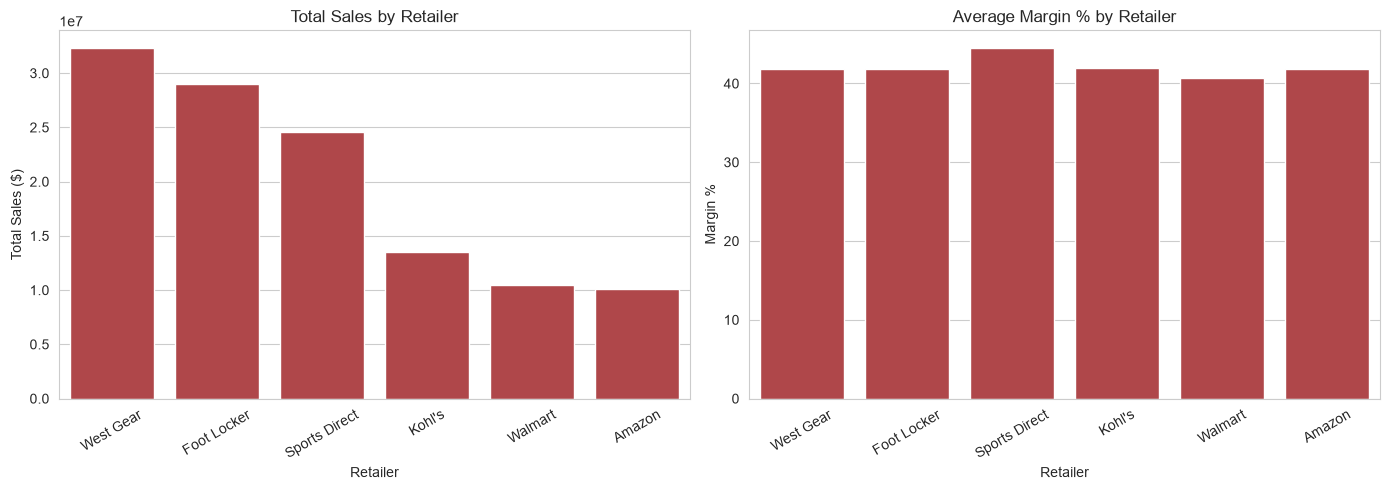

,Total_Sales,Avg_Margin,Sales Share %
Retailer,,,
West Gear,"32,317,808.00",41.79,26.90
Foot Locker,"28,953,945.00",41.79,24.10
Sports Direct,"24,537,997.00",44.50,20.50
Kohl's,"13,512,453.00",41.92,11.30
Walmart,"10,506,085.00",40.65,8.80
Amazon,"10,096,987.00",41.79,8.40


In [11]:
retailer_sales = data.groupby('Retailer').agg(
    Total_Sales=('Total Sales', 'sum'),
    Avg_Margin=('Margin %', 'mean')
).sort_values('Total_Sales', ascending=False)
retailer_sales['Sales Share %'] = (retailer_sales['Total_Sales'] / retailer_sales['Total_Sales'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=retailer_sales.index, y=retailer_sales['Total_Sales'], ax=axes[0])
axes[0].set_title('Total Sales by Retailer')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=retailer_sales.index, y=retailer_sales['Avg_Margin'], ax=axes[1])
axes[1].set_title('Average Margin % by Retailer')
axes[1].set_ylabel('Margin %')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

retailer_sales


### 5.2 Regional performance

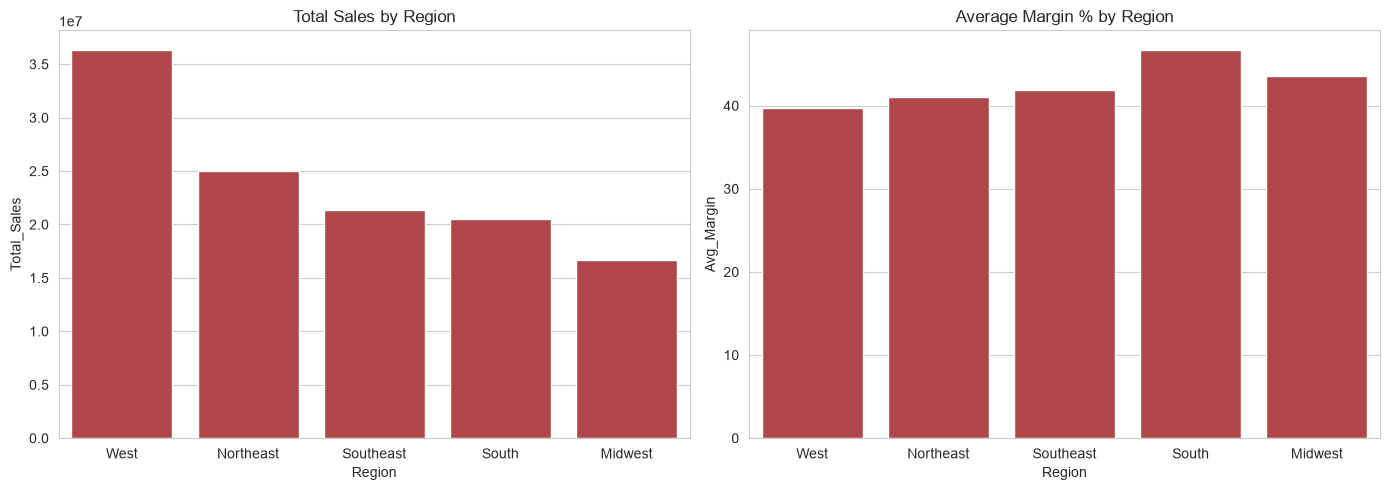

,Total_Sales,Avg_Margin,Sales Share %
Region,,,
West,"36,344,407.00",39.67,30.30
Northeast,"25,027,267.00",41.05,20.90
Southeast,"21,374,436.00",41.92,17.80
South,"20,524,731.00",46.71,17.10
Midwest,"16,654,434.00",43.53,13.90


In [12]:
region_sales = data.groupby('Region').agg(
    Total_Sales=('Total Sales', 'sum'), Avg_Margin=('Margin %', 'mean')
).sort_values('Total_Sales', ascending=False)
region_sales['Sales Share %'] = (region_sales['Total_Sales'] / region_sales['Total_Sales'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=region_sales.index, y=region_sales['Total_Sales'], ax=axes[0])
axes[0].set_title('Total Sales by Region')
sns.barplot(x=region_sales.index, y=region_sales['Avg_Margin'], ax=axes[1])
axes[1].set_title('Average Margin % by Region')
plt.tight_layout()
plt.show()

region_sales


### 5.3 Product category performance

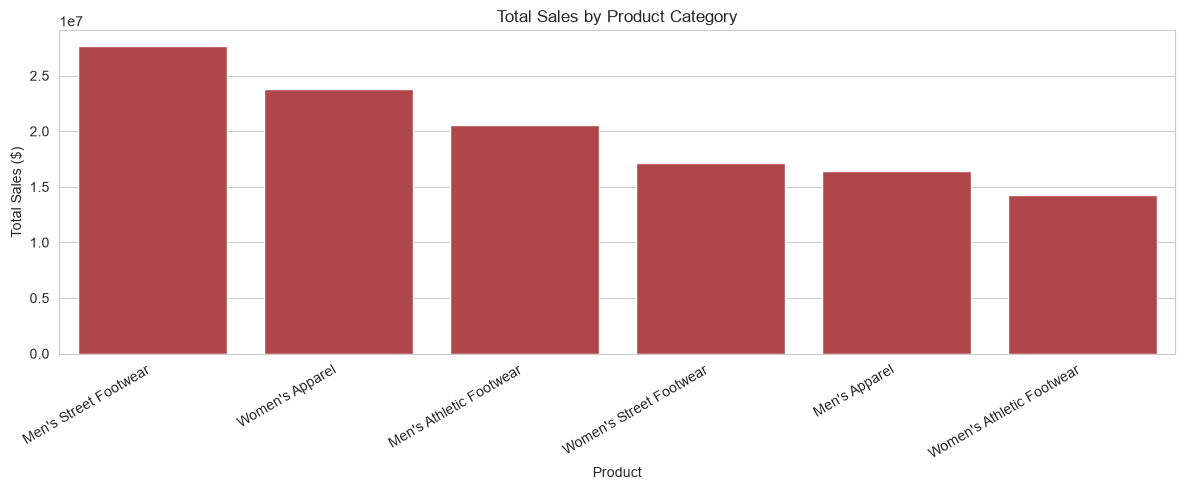

,Total_Sales,Avg_Margin,Sales Share %
Product,,,
Men's Street Footwear,"27,680,769.00",44.61,23.10
Women's Apparel,"23,814,985.00",44.15,19.90
Men's Athletic Footwear,"20,532,180.00",40.27,17.10
Women's Street Footwear,"17,171,938.00",41.03,14.30
Men's Apparel,"16,413,882.00",41.32,13.70
Women's Athletic Footwear,"14,311,521.00",42.42,11.90


In [13]:
product_sales = data.groupby('Product').agg(
    Total_Sales=('Total Sales', 'sum'), Avg_Margin=('Margin %', 'mean')
).sort_values('Total_Sales', ascending=False)
product_sales['Sales Share %'] = (product_sales['Total_Sales'] / product_sales['Total_Sales'].sum() * 100).round(1)

plt.figure(figsize=(12, 5))
graph = sns.barplot(x=product_sales.index, y=product_sales['Total_Sales'])
plt.xticks(rotation=30, ha='right')
plt.title('Total Sales by Product Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

product_sales


### 5.4 Sales channel performance

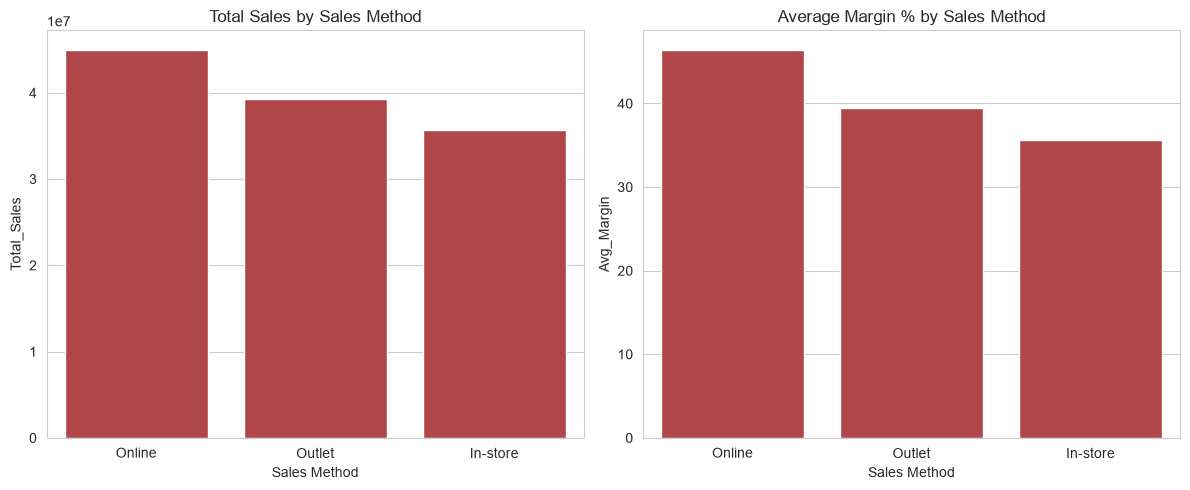

,Total_Sales,Avg_Margin,Transactions,Sales Share %
Sales Method,,,,
Online,"44,965,657.00",46.41,4887,37.50
Outlet,"39,295,243.00",39.50,3008,32.80
In-store,"35,664,375.00",35.61,1740,29.70


In [14]:
method_sales = data.groupby('Sales Method').agg(
    Total_Sales=('Total Sales', 'sum'), Avg_Margin=('Margin %', 'mean'), Transactions=('Total Sales', 'count')
).sort_values('Total_Sales', ascending=False)
method_sales['Sales Share %'] = (method_sales['Total_Sales'] / method_sales['Total_Sales'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=method_sales.index, y=method_sales['Total_Sales'], ax=axes[0])
axes[0].set_title('Total Sales by Sales Method')
sns.barplot(x=method_sales.index, y=method_sales['Avg_Margin'], ax=axes[1])
axes[1].set_title('Average Margin % by Sales Method')
plt.tight_layout()
plt.show()

method_sales


### 5.5 Monthly sales trend

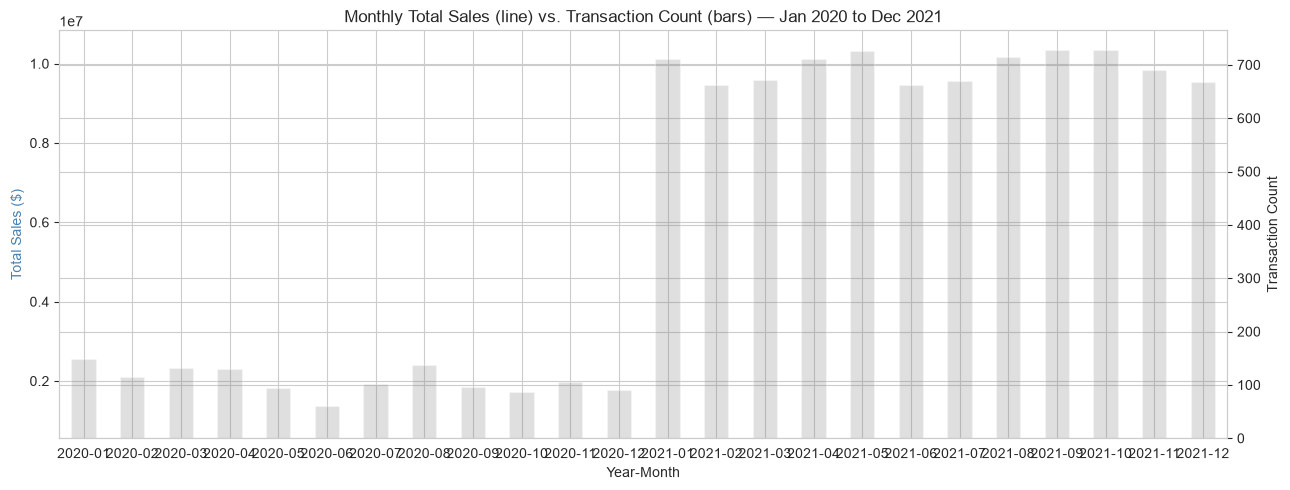

Avg. transactions/month in 2020: 108
Avg. transactions/month in 2021: 695
Distinct retailers reporting in 2020: 5
Distinct retailers reporting in 2021: 6


In [15]:
data['Year-Month'] = data['Invoice Date'].dt.to_period('M')
monthly = data.groupby('Year-Month')['Total Sales'].sum()
monthly_counts = data.groupby('Year-Month').size()

fig, ax1 = plt.subplots(figsize=(13, 5))
monthly.plot(ax=ax1, marker='o', color='steelblue', label='Total Sales')
ax1.set_ylabel('Total Sales ($)', color='steelblue')
ax1.set_title('Monthly Total Sales (line) vs. Transaction Count (bars) — Jan 2020 to Dec 2021')

ax2 = ax1.twinx()
monthly_counts.plot(ax=ax2, kind='bar', alpha=0.25, color='gray', label='Transaction Count')
ax2.set_ylabel('Transaction Count')
plt.tight_layout()
plt.show()

print("Avg. transactions/month in 2020:", round(monthly_counts['2020-01':'2020-12'].mean()))
print("Avg. transactions/month in 2021:", round(monthly_counts['2021-01':'2021-12'].mean()))
print("Distinct retailers reporting in 2020:", data.loc[data['Year']==2020, 'Retailer'].nunique())
print("Distinct retailers reporting in 2021:", data.loc[data['Year']==2021, 'Retailer'].nunique())


**Important caveat, correcting a common misreading of this dataset:** it's tempting to read 2021 vastly outselling 2020 as "COVID recovery." The transaction-count overlay shows why that's not a safe conclusion: 2020 only has ~108 transactions/month from 5 retailers, while 2021 has ~695/month from 6 retailers. The 2020 sample is simply much thinner — likely a partial-year extract — so a direct revenue comparison between the two years is comparing very different sample sizes, not comparable time periods. Any YoY narrative should be caveated or dropped rather than presented as a finding.

## 6. Statistical Testing



### 6.1 Does sales channel affect margin?

In [16]:
groups = [g['Margin %'].values for _, g in data.groupby('Sales Method')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA — Sales Method vs Margin %:  F = {f_stat:.2f}, p = {p_val:.2e}")

online = data.loc[data['Sales Method'] == 'Online', 'Margin %']
outlet = data.loc[data['Sales Method'] == 'Outlet', 'Margin %']
t_stat, p_val2 = stats.ttest_ind(online, outlet, equal_var=False)
print(f"\nWelch's t-test — Online vs Outlet margin: t = {t_stat:.2f}, p = {p_val2:.2e}")
print(f"Online mean margin: {online.mean():.2f}%   Outlet mean margin: {outlet.mean():.2f}%")


One-way ANOVA — Sales Method vs Margin %:  F = 1220.41, p = 0.00e+00

Welch's t-test — Online vs Outlet margin: t = 32.77, p = 2.94e-217
Online mean margin: 46.41%   Outlet mean margin: 39.50%


**Result:** the difference across channels is highly significant (p < 0.001) and not small — Online margin averages ~7 points above Outlet, ~11 above In-store. This is explored further in the regression below to see if it holds after controlling for region and product mix.

### 6.2 Does season affect per-transaction sales value?

In [17]:
groups_season = [g['Total Sales'].values for _, g in data.groupby('Season')]
f2, p2 = stats.f_oneway(*groups_season)
print(f"One-way ANOVA — Season vs Total Sales (per transaction): F = {f2:.2f}, p = {p2:.2e}")
data.groupby('Season')['Total Sales'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)


One-way ANOVA — Season vs Total Sales (per transaction): F = 35.70, p = 6.20e-23


,mean,median,count
Season,,,
Summer,"14,726.41","9,080.50",2346
Winter,"12,236.19","7,936.00",2393
Autumn,"11,495.18","7,182.00",2433
Spring,"11,420.27","6,960.00",2463


**Result:** statistically significant, but the effect size is modest compared to channel/region — worth noting, not worth leading a strategy with.

### 6.3 Correlation structure

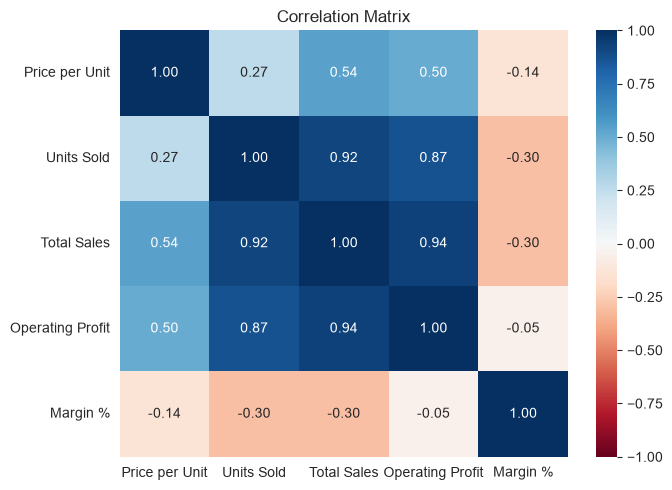

In [18]:
corr_cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Margin %']
corr = data[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


**Result:** `Margin %` correlates negatively with `Units Sold` (-0.30) — high-volume transactions tend to run thinner margins, consistent with bulk/wholesale-style pricing. `Total Sales` is driven almost entirely by `Units Sold` (0.92), much more than by `Price per Unit` (0.54).

## 7. What Actually Drives Margin? (Regression)

The EDA above shows channel, region, and product each look associated with margin individually — but they're correlated with each other (e.g. certain regions may lean on certain channels). An OLS regression puts all factors in the same model so each coefficient reflects its effect *holding the others constant*.

In [19]:
model = smf.ols(
    "Q('Margin %') ~ Q('Price per Unit') + Q('Units Sold') "
    "+ C(Q('Sales Method')) + C(Region) + C(Product) + C(Season)",
    data=data
).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          Q('Margin %')   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     286.7
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:42:42   Log-Likelihood:                -33702.
No. Observations:                9635   AIC:                         6.744e+04
Df Residuals:                    9618   BIC:                         6.756e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

**Interpretation** (all effects below are *relative to the model's baseline category* — In-store channel, Midwest region, Men's Apparel product, Autumn season — and each is statistically significant at p < 0.01 unless noted):

- **Channel dominates.** Selling **Online** carries a **+7.8 percentage-point margin premium** over In-store; Outlet carries a smaller **+1.3pp** premium. This is the single largest effect in the model — bigger than any region or product effect.
- **Region matters independently of channel.** **South** is **+4.3pp**, while **West** is **−2.0pp** — despite West being the top region by total revenue. This means West's revenue leadership comes with a below-average margin profile, not because of what it sells, but as a regional effect on its own.
- **Product mix has a real, secondary effect.** **Men's Street Footwear (+4.9pp)** and **Women's Apparel (+3.7pp)** carry higher margins than the baseline; Men's Athletic Footwear and Women's Street Footwear are statistically indistinguishable from baseline.
- **Season is mostly noise once other factors are controlled for** — only Winter is significant, and only a small −0.6pp. The seasonal story in the raw EDA is largely explained by channel/region/product mix shifting across the year, not season itself.
- **Volume has a small negative effect** (Units Sold coefficient ≈ −0.01pp per unit) confirming the bulk-discount pattern seen in the correlation matrix — but the magnitude is tiny next to the channel effect.
- The model explains **~32% of the variance in margin** (R² = 0.32) — real signal, but plenty of variation is transaction-specific and not explained by these categorical factors alone.


## 8. Retailer × Region Segmentation

Revenue and margin, viewed independently, hide combinations that are simultaneously large *and* underperforming. This view treats each Retailer × Region pair as a unit and plots volume against margin to flag both opportunities and risks.

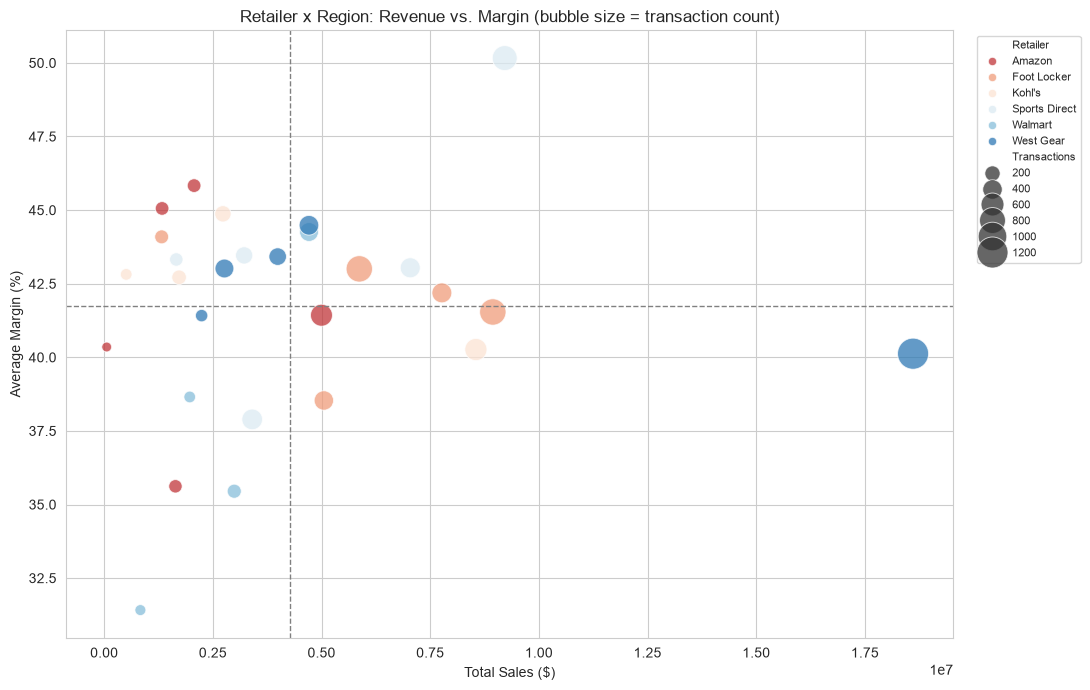

Highest revenue, lowest margin combinations (bottom-right quadrant risk):


,Retailer,Region,Total_Sales,Avg_Margin,Transactions
27,West Gear,West,"18,608,230.00",40.12,1205
6,Foot Locker,Northeast,"8,940,649.00",41.54,834
13,Kohl's,West,"8,551,190.00",40.26,550
9,Foot Locker,West,"5,053,709.00",38.53,396
1,Amazon,Northeast,"4,998,840.00",41.43,541
15,Sports Direct,Northeast,"3,404,772.00",37.89,462
21,Walmart,Southeast,"2,992,039.00",35.45,150
26,West Gear,Southeast,"2,241,428.00",41.42,91


In [20]:
seg = data.groupby(['Retailer', 'Region']).agg(
    Total_Sales=('Total Sales', 'sum'),
    Avg_Margin=('Margin %', 'mean'),
    Transactions=('Total Sales', 'count')
).reset_index()

plt.figure(figsize=(11, 7))
scatter = sns.scatterplot(
    data=seg, x='Total_Sales', y='Avg_Margin', size='Transactions',
    hue='Retailer', sizes=(50, 500), alpha=0.75, legend='brief'
)
plt.axhline(seg['Avg_Margin'].mean(), color='gray', linestyle='--', linewidth=1)
plt.axvline(seg['Total_Sales'].mean(), color='gray', linestyle='--', linewidth=1)
plt.xlabel('Total Sales ($)')
plt.ylabel('Average Margin (%)')
plt.title('Retailer x Region: Revenue vs. Margin (bubble size = transaction count)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print("Highest revenue, lowest margin combinations (bottom-right quadrant risk):")
seg.sort_values(['Total_Sales', 'Avg_Margin'], ascending=[False, True]).query("Avg_Margin < @seg['Avg_Margin'].mean()").head(8)


**Reading the quadrants:**
- **Top-right (high revenue, high margin):** `West Gear`–West and `Sports Direct`–South are the strongest combinations — high volume *and* above-average margin. These are the partnerships to protect and potentially expand.
- **Bottom-right (high revenue, below-average margin):** `West Gear`–West still leads on revenue but sits right at the margin average — worth monitoring but not urgent.
- **Flagged risk:** `Walmart`–West combines meaningful revenue exposure with the **lowest average margin of any combination in the dataset (31.4%)**, well below the ~41% dataset-wide average. This is the clearest renegotiation target — either a pricing/terms conversation with Walmart in that region, or a deliberate shift of volume toward higher-margin channels (Online) for that partnership.


## 9. Short-Horizon Sales Forecast

A simple linear trend on monthly totals — not a production forecasting model, but enough to give a directional next-quarter estimate and demonstrate the workflow. Given the 2020/2021 coverage gap noted earlier, the trend is fit on **2021 data only**, which is the reliable, consistently-sampled period.

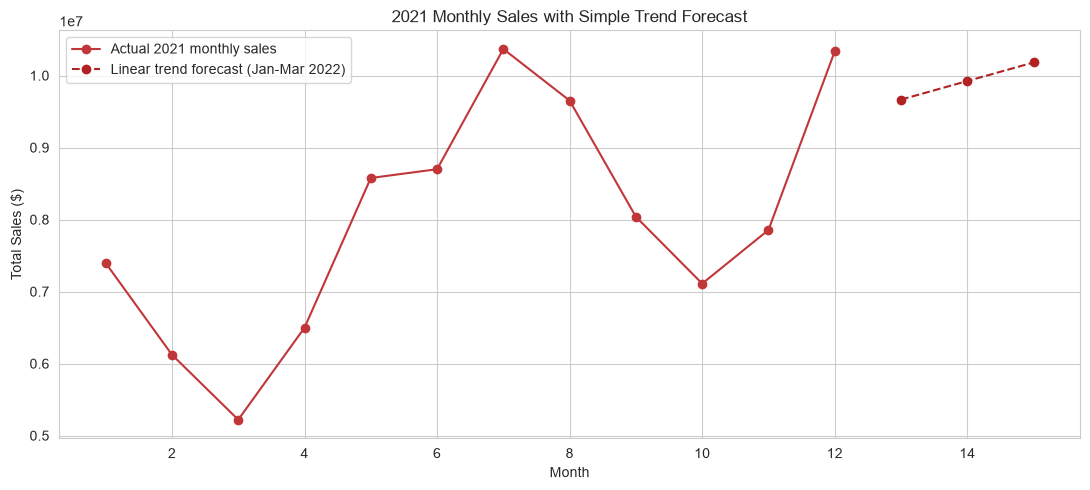

Fitted monthly growth (2021 only): $257854/month
Jan 2022 forecast: $9,665,516
Feb 2022 forecast: $9,923,370
Mar 2022 forecast: $10,181,223


In [21]:
monthly_2021 = data.loc[data['Year'] == 2021].groupby('Month')['Total Sales'].sum()

x = np.arange(len(monthly_2021))
y = monthly_2021.values
slope, intercept = np.polyfit(x, y, 1)
trend = np.poly1d([slope, intercept])

future_months = np.arange(len(monthly_2021), len(monthly_2021) + 3)
forecast = trend(future_months)

plt.figure(figsize=(11, 5))
plt.plot(monthly_2021.index, y, marker='o', label='Actual 2021 monthly sales')
plt.plot([13, 14, 15], forecast, marker='o', linestyle='--', color='firebrick', label='Linear trend forecast (Jan-Mar 2022)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('2021 Monthly Sales with Simple Trend Forecast')
plt.legend()
plt.tight_layout()
plt.show()

print("Fitted monthly growth (2021 only): $%.0f/month" % slope)
for m, val in zip(['Jan 2022', 'Feb 2022', 'Mar 2022'], forecast):
    print(f"{m} forecast: ${val:,.0f}")


**Caveat:** a linear trend on 12 noisy monthly points is a directional signal, not a production forecast — it ignores seasonality (Summer/Winter effects seen in section 5) and any retailer-specific dynamics. A next step (see Limitations) would be a seasonal model (e.g. Holt-Winters or SARIMA) once more years of consistent data are available.

## 10. Key Findings & Recommendations

| # | Finding | Recommendation |
|---|---------|-----------------|
| 1 | Online carries a +7.8pp margin premium over In-store, and +6.5pp over Outlet, after controlling for region/product/season | Shift acquisition/marketing spend toward growing the Online channel specifically with retailers that currently under-index on it (e.g. Walmart, Amazon — see channel mix below) |
| 2 | West region generates the most revenue ($36.3M) but runs a below-average margin (−2.0pp vs. baseline); South is smaller but the highest-margin region (+4.3pp) | Don't optimize the West relationship purely on revenue growth — investigate West's pricing/discounting practices; use South's channel/pricing mix as an internal benchmark |
| 3 | `Walmart`–West is the clearest underperforming combination: real revenue exposure, lowest margin in the dataset (31.4%) | Prioritize this pairing for a pricing/terms review or a deliberate channel-mix shift toward Online |
| 4 | Men's Street Footwear and Women's Apparel are both high-revenue *and* high-margin categories (+4.9pp, +3.7pp) | Weight future inventory/marketing investment toward these two categories over lower-margin footwear lines |
| 5 | Season has a real but small effect on margin (mostly not significant once other factors are controlled for) | Don't build a major strategy around seasonality alone — it's a minor factor next to channel and region |
| 6 | The "2021 sales > 2020" pattern is a sampling artifact (2020 has ~1/6th the monthly transaction volume and one fewer retailer) | Don't report this as a YoY growth or COVID-recovery story without first correcting for the coverage gap |


## 11. Limitations & Next Steps

- **Sample coverage:** 2020 is thin and covers fewer retailers than 2021 — any year-over-year comparison in this dataset should be treated with caution, and a longer, more consistently-sampled history would be needed for real trend analysis.
- **Regression scope:** the OLS model explains ~32% of margin variance — there's clearly transaction-level variation (e.g. individual store negotiations, promotions) not captured by the categorical factors used here. A next iteration could add interaction terms (e.g. Region × Sales Method) or a tree-based model (e.g. gradient boosting) to capture non-linear effects and check whether it meaningfully beats the linear model.
- **Forecast:** the 3-month forecast is a simple linear trend for demonstration; a seasonal model (Holt-Winters, SARIMA, or Prophet) fit on more history would be more production-appropriate.
- **Causality:** the regression identifies *associations*, not causal effects — e.g. we can't conclude that switching a specific retailer to Online *would* raise its margin by 7.8pp without a controlled test (e.g. an A/B rollout by store).
- **External data:** no cost, marketing spend, or macroeconomic data (e.g. actual COVID timeline, unemployment, retail foot-traffic indices) is joined in — that would be needed to properly explain the 2020→2021 shift rather than just flagging it as a coverage issue.
